# RQ1 factor C - reranking

**What varies:** whether a cross-encoder reorders the candidate list, two levels.
**What is held constant:** 512-unit sliding-window segments, BGE-small dense retrieval for
the candidate list, candidate depth 20, context depth 5, all 910 questions.

**The centre point.** Every notebook varies one factor and holds the rest at 512-unit sliding
window segments with 10% overlap, BGE-small dense retrieval, no reranking, candidate depth 20
and context depth 5. That is what makes each measurement a *main effect*: no arm differs from
the centre in two ways at once.

**Levels:** reranking off *(centre point)*, and `BAAI/bge-reranker-base` over the top 20
dense candidates.

Two optional extras, both off by default: reranking at depth 50, and reranking on top of the
hybrid list rather than the dense one. Each is a second factor, so neither belongs in the
main-effect estimate; they are reported separately as a sensitivity check.

### Why this is much faster than the earlier notebook
The cross-encoder is called **once** for the whole experiment, over every (query, segment)
pair at batch size 128 in half precision. Calling it per question on 20 pairs leaves the GPU
idle between calls; Table 5.2 recorded 435.69 seconds for that pattern on 450 questions.

**Runtime:** about 10 minutes for 910 questions x 20 segments.

## 1. Open the shared cache

In [1]:
# Load the shared library written by notebook 00 and open the same cache.
import sys, os
from google.colab import drive
drive.mount('/content/drive')
PROJECT = '/content/drive/MyDrive/techqa_rq1'
assert os.path.exists(PROJECT + '/rq1_core.py'), (
    'rq1_core.py not found. Run RQ1_00_Build_Once.ipynb first - it writes the library '
    'and builds the chunk tables and embeddings that this notebook reads from cache.')
sys.path.insert(0, PROJECT)
import rq1_core as C
import numpy as np, pandas as pd, time, json
C.setup(project_dir=PROJECT)
print('GPU:', C.gpu_name())

Mounted at /content/drive
rq1_core 1.0 | profile=fast | run tag u512_o10_p0
  cache   -> /content/drive/MyDrive/techqa_rq1/cache_u512_o10_p0
  outputs -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0
GPU: Tesla T4


In [2]:
# The whole labelled dataset, on the fast local disk.
# Notebook 00 mirrors the four extracted files to Drive, so this fresh runtime restores them
# with a file copy (~1 min) instead of re-downloading and re-extracting the archive (~5 min).
if not C.dataset_present():
    if C.dataset_mirrored():
        print('restoring the corpus from the Drive mirror ...')
        C.restore_dataset_from_mirror()
    else:
        dl, ex = C.download_commands()
        get_ipython().system(dl)
        get_ipython().system(ex)
        C.mirror_dataset()
ds = C.load_dataset()
print(json.dumps(ds.summary(), indent=1))

restoring the corpus from the Drive mirror ...
{
 "questions": 910,
 "answerable": 610,
 "unanswerable": 300,
 "per_split": {
  "train": [
   600,
   450
  ],
  "dev": [
   310,
   160
  ]
 },
 "technotes": 28482,
 "candidate_technotes": 28461
}


## 2. Configuration for this factor

In [3]:
C.CFG.RERANK_DEPTH = 20
RUN_DEPTH_50    = False   # sensitivity check: rerank the top 50 instead of the top 20
RUN_ON_HYBRID   = False   # sensitivity check: rerank the hybrid-RRF list instead of the dense one
print('rerank depth', C.CFG.RERANK_DEPTH, '| model', C.CFG.RERANKER_MODEL)

rerank depth 20 | model BAAI/bge-reranker-base


## 3. Dense candidates, then one batched reranking pass

In [4]:
idx = C.load_method_index(ds, C.CFG.BASELINE_METHOD, with_bm25=RUN_ON_HYBRID)
base = {q['QUESTION_ID']: idx.rank(q, 'dense') for q in ds.questions}
print(f'{len(base)} candidate lists ready')

from sentence_transformers import CrossEncoder
ce = CrossEncoder(C.CFG.RERANKER_MODEL, max_length=512, device=C.device())
if C.device() == 'cuda':
    ce.model.half()

reranked, rerank_s = C.rerank_batch(idx, ds.questions, base, depth=20, batch_size=128, model=ce)
n_pairs = sum(min(20, len(v)) for v in base.values())
print(f'{n_pairs:,} (query, segment) pairs scored in {rerank_s:.0f}s '
      f'= {1000*rerank_s/max(1,len(ds.questions)):.0f} ms per question')

910 candidate lists ready


config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

Batches:   0%|          | 0/143 [00:00<?, ?it/s]

18,200 (query, segment) pairs scored in 114s = 125 ms per question


In [5]:
frames, contexts = [], {}
off, lat_off = C.run_arm(idx, ds.questions, 'dense', arm_name='off')
off['rerank_level'] = 'off'
on, _ = C.run_arm(idx, ds.questions, 'dense', reranked=reranked, arm_name='cross_encoder')
on['rerank_level'] = 'cross_encoder'
Cf = pd.concat([off, on], ignore_index=True)
contexts['off'] = {q['QUESTION_ID']: C.top_context(idx, q, 'dense').tolist()
                   for q in ds.questions}
contexts['cross_encoder'] = {qid: np.asarray(v)[:C.CFG.CONTEXT_K].tolist()
                             for qid, v in reranked.items()}
json.dump(contexts, open(C.PATHS.CACHE / 'contexts_factorC.json', 'w'))
C.save_table(Cf, 'rq1_factorC_per_question')
print('rows:', len(Cf))

  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorC_per_question.csv
rows: 1220


## 4. The metric profile with and without reranking

,rerank_level,n,nDCG@5,Recall@20,MRR,gold_span_coverage,context_precision@5,context_recall@5,gold_document_in_top_5,chunk_boundary_loss
1,off,610,0.5693,0.8246,0.5530,0.6436,0.1298,0.6436,0.6672,0.0262
0,cross_encoder,610,0.5243,0.8246,0.5077,0.6016,0.1216,0.6016,0.6246,0.0230


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorC_summary.csv
  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_factorC_profile.png


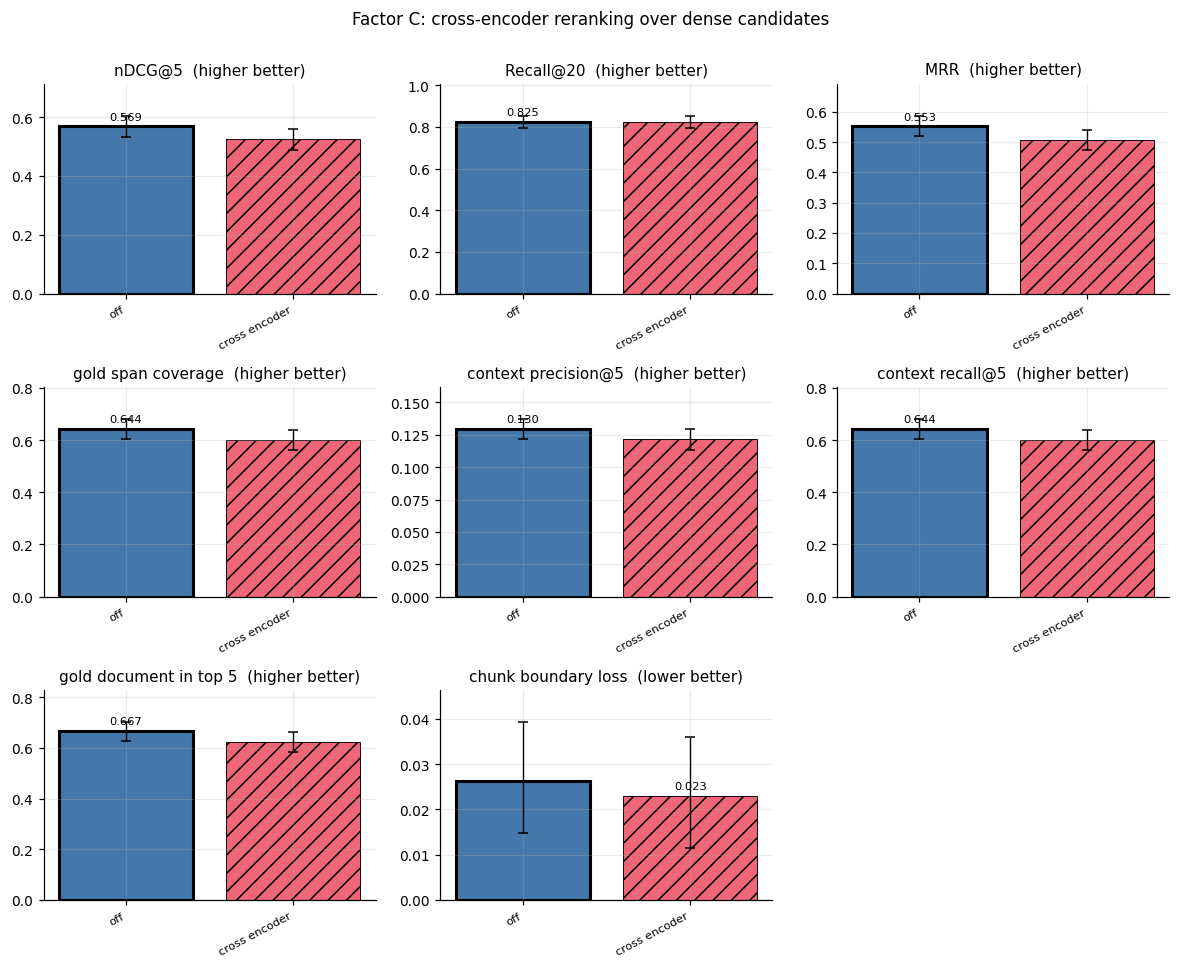

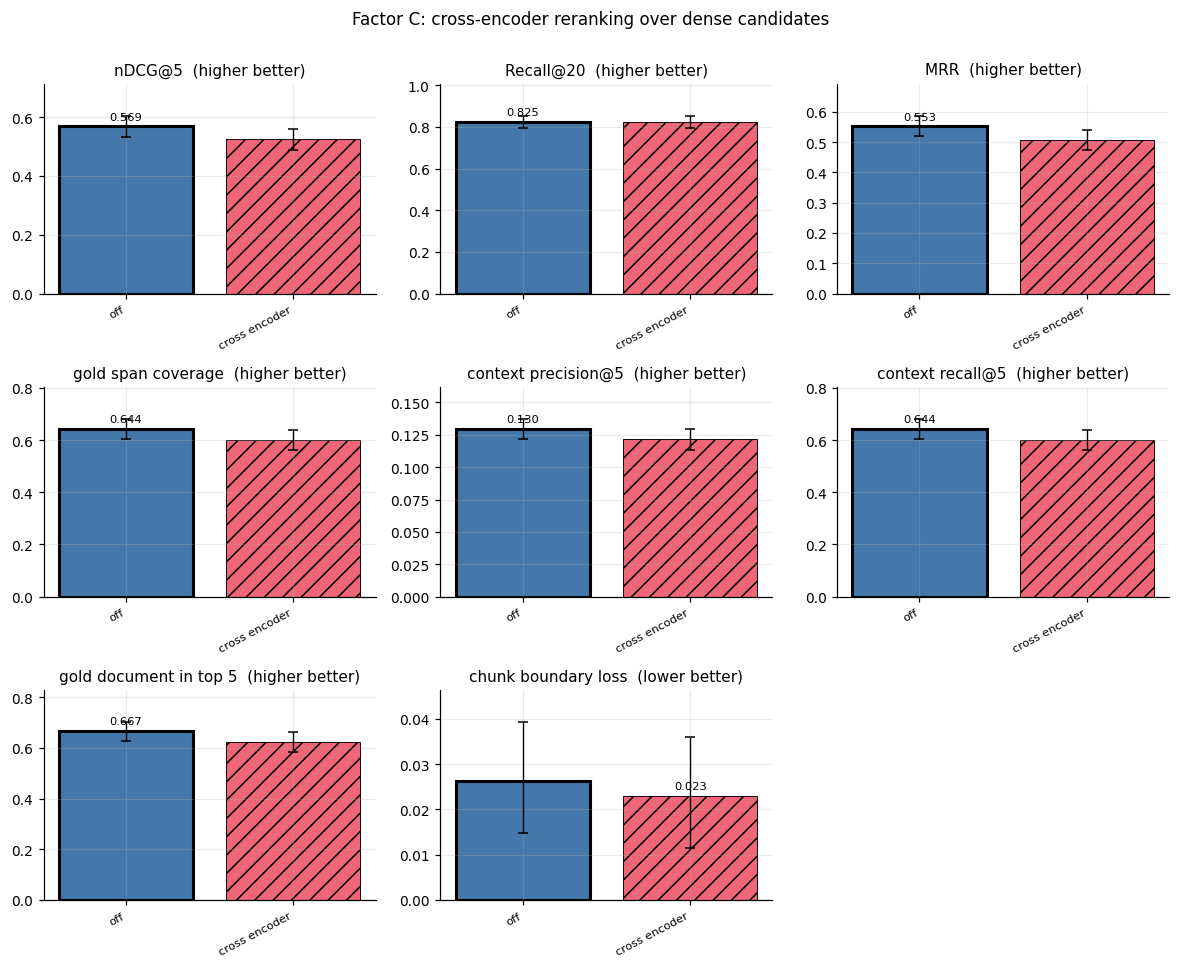

In [6]:
METRICS = C.RETRIEVAL_METRICS
summary_C = C.arm_summary(Cf, ['rerank_level'], METRICS)
summary_C['rerank_level'] = pd.Categorical(summary_C['rerank_level'],
                                           categories=['off', 'cross_encoder'], ordered=True)
summary_C = summary_C.sort_values('rerank_level')
display(summary_C[['rerank_level', 'n'] + METRICS].round(4))
C.save_table(summary_C, 'rq1_factorC_summary')
C.plot_metric_bars(summary_C, 'rerank_level', METRICS,
    'Factor C: cross-encoder reranking over dense candidates', 'fig_rq1_factorC_profile',
    baseline='off',
    caption='Retrieval-evidence profile with and without cross-encoder reranking of the top '
            '20 dense candidates, over all 610 answerable TechQA questions. Error bars are '
            '95% bootstrap intervals over questions.')

In [7]:
contrasts_C = C.pairwise_against_baseline(Cf, 'rerank_level', 'off', METRICS)
display(contrasts_C[['metric', 'mean_diff', 'lo', 'hi', 'p_holm', 'significant', 'n']]
        .round(4))
C.save_table(contrasts_C, 'rq1_factorC_contrasts')
for _, r in contrasts_C[contrasts_C.metric.isin(['nDCG@5', 'gold_span_coverage'])].iterrows():
    print('\n' + C.describe_contrast(r))

,metric,mean_diff,lo,hi,p_holm,significant,n
0,nDCG@5,-0.0450,-0.0733,-0.0157,0.0000,True,610
1,Recall@20,0.0000,0.0000,0.0000,1.0000,False,610
2,MRR,-0.0452,-0.0730,-0.0168,0.0004,True,610
3,gold_span_coverage,-0.0419,-0.0734,-0.0092,0.0108,True,610
4,context_precision@5,-0.0082,-0.0144,-0.0016,0.0156,True,610
5,context_recall@5,-0.0419,-0.0734,-0.0092,0.0108,True,610
6,gold_document_in_top_5,-0.0426,-0.0738,-0.0115,0.0080,True,610
7,chunk_boundary_loss,-0.0033,-0.0180,0.0115,0.7552,False,610


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorC_contrasts.csv

cross encoder against off gives a mean difference of -0.0450 in nDCG@5, with a 95% interval from -0.0733 to -0.0157 over 610 paired questions. The interval excludes zero.

cross encoder against off gives a mean difference of -0.0419 in gold span coverage, with a 95% interval from -0.0734 to -0.0092 over 610 paired questions. The interval excludes zero.


## 5. What reranking does and does not move

Reranking cannot put a document into the candidate pool, so Recall@20 is fixed by construction. Its only lever is promotion inside that pool. Splitting the questions by whether the gold document was already in the top five says whether it rescues questions or disturbs ones that were already right.

In [8]:
w5 = C.to_wide(Cf, 'gold_document_in_top_5', 'rerank_level')
rescued = int(((w5.off == 0) & (w5.cross_encoder == 1)).sum())
broken  = int(((w5.off == 1) & (w5.cross_encoder == 0)).sum())
recall_fixed = bool(np.allclose(C.to_wide(Cf, 'Recall@20', 'rerank_level').off,
                                C.to_wide(Cf, 'Recall@20', 'rerank_level').cross_encoder))
effect = {'questions': int(len(w5)), 'rescued_into_context': rescued,
          'demoted_out_of_context': broken, 'net': rescued - broken,
          'recall_at_20_unchanged': recall_fixed,
          'rerank_seconds_total': rerank_s,
          'rerank_ms_per_question': 1000 * rerank_s / max(1, len(ds.questions))}
print(json.dumps(effect, indent=1))
C.save_results(effect, 'rq1_factorC_promotion')

{
 "questions": 610,
 "rescued_into_context": 35,
 "demoted_out_of_context": 61,
 "net": -26,
 "recall_at_20_unchanged": true,
 "rerank_seconds_total": 113.50146767499996,
 "rerank_ms_per_question": 124.72688755494501
}
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorC_promotion.json


PosixPath('/content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorC_promotion.json')

## 6. Sensitivity checks (optional)

Each of these changes a second thing, so they are reported apart from the main effect.

In [9]:
extras = []
if RUN_DEPTH_50:
    rr50, s50 = C.rerank_batch(idx, ds.questions, base, depth=50, batch_size=128, model=ce)
    d50, _ = C.run_arm(idx, ds.questions, 'dense', reranked=rr50, arm_name='cross_encoder_d50')
    d50['rerank_level'] = 'cross_encoder_d50'
    extras.append(d50)
    print(f'depth 50: {s50:.0f}s')
if RUN_ON_HYBRID:
    hyb = {q['QUESTION_ID']: idx.rank(q, 'hybrid_rrf') for q in ds.questions}
    rrh, sh = C.rerank_batch(idx, ds.questions, hyb, depth=20, batch_size=128, model=ce)
    dh, _ = C.run_arm(idx, ds.questions, 'hybrid_rrf', reranked=rrh, arm_name='rerank_on_hybrid')
    dh['rerank_level'] = 'rerank_on_hybrid'
    extras.append(dh)
    print(f'on hybrid: {sh:.0f}s')
if extras:
    extra_df = pd.concat([Cf] + extras, ignore_index=True)
    s = C.arm_summary(extra_df, ['rerank_level'], METRICS)
    display(s[['rerank_level', 'n'] + METRICS].round(4))
    C.save_table(s, 'rq1_factorC_sensitivity')
else:
    print('sensitivity checks not run (both flags are False)')

sensitivity checks not run (both flags are False)


## 7. What factor C contributes to RQ1

In [10]:
del ce; C.free_gpu()
cost_C = pd.DataFrame([
    {'rerank_level': 'off', 'retrieval_ms': lat_off * 1000, 'rerank_ms': 0.0},
    {'rerank_level': 'cross_encoder', 'retrieval_ms': lat_off * 1000,
     'rerank_ms': 1000 * rerank_s / max(1, len(ds.questions))}])
cost_C['total_query_ms'] = cost_C.retrieval_ms + cost_C.rerank_ms
display(cost_C.round(2))
C.save_table(cost_C, 'rq1_factorC_cost')

eff_C = C.repeated_measures_effect(C.to_wide(Cf, 'nDCG@5', 'rerank_level'))
C.save_results({'effect_nDCG@5': eff_C, 'summary': summary_C.to_dict(orient='records'),
                'promotion': effect, 'cost': cost_C.to_dict(orient='records'),
                'provenance': C.stamp({'factor': 'reranking'})}, 'rq1_factorC')
print(f"Reranking, nDCG@5: levels span {eff_C['range']:.4f} "
      f"(95% CI {eff_C['range_lo']:.4f} to {eff_C['range_hi']:.4f}), "
      f"partial eta-squared {eff_C['eta2_partial']:.4f}, best level {eff_C['best_level']}.")
print(f"Cost of that: {cost_C.total_query_ms.iloc[1] / max(1e-9, cost_C.total_query_ms.iloc[0]):.0f}x "
      f"the query time of the centre point.")
print('\nFactor C complete. Run RQ1_D_Generation_Profile.ipynb next.')

,rerank_level,retrieval_ms,rerank_ms,total_query_ms
0,off,0.05,0.00,0.05
1,cross_encoder,0.05,124.73,124.77


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorC_cost.csv
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorC.json
Reranking, nDCG@5: levels span 0.0450 (95% CI 0.0157 to 0.0733), partial eta-squared 0.0156, best level off.
Cost of that: 2731x the query time of the centre point.

Factor C complete. Run RQ1_D_Generation_Profile.ipynb next.
